# 03 - Regresja: czas okrazenia

Cel: przewidziec `LapTime_s` z cech znanych dla okrazenia (opona, jej wiek, paliwo
przez nr okrazenia, zespol, pogoda).

Model glowny: **HistGradientBoostingRegressor** (nieliniowy, natywne kategorie i NaN).
Baseline: regresja liniowa - do porownania.

**Split per wyscig** (`GroupShuffleSplit` po `Round`): okrazenia z jednego GP nie moga
trafic naraz do treningu i testu - inaczej model 'podejrzy' warunki danego wyscigu.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

laps = pd.read_parquet('../data/laps_clean.parquet')
laps['circuit'] = laps['EventName']

cat_cols = ['Compound', 'Team', 'circuit']
num_cols = ['TyreLife', 'FreshTyre', 'Stint', 'LapNumber',
            'AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'Rainfall']
features = cat_cols + num_cols
target = 'LapTime_s'

X = laps[features].copy()
X['FreshTyre'] = X['FreshTyre'].astype(int)
y = laps[target].values
groups = laps['Round'].values

In [2]:
# split po wyscigu
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(gss.split(X, y, groups))
X_tr, X_te, y_tr, y_te = X.iloc[tr], X.iloc[te], y[tr], y[te]
print('train laps:', len(X_tr), '| test laps:', len(X_te))
print('wyscigi w tescie:', sorted(set(groups[te])))

train laps: 16061 | test laps: 4542
wyscigi w tescie: [np.int64(1), np.int64(9), np.int64(10), np.int64(12), np.int64(17), np.int64(19)]


### Baseline: regresja liniowa

In [3]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols),
])
lin = Pipeline([('pre', pre), ('reg', LinearRegression())])
lin.fit(X_tr, y_tr)
p_lin = lin.predict(X_te)

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<22} MAE={mae:.3f}s  RMSE={rmse:.3f}s  R2={r2:.3f}')
    return mae, rmse, r2

report('Linear (baseline)', y_te, p_lin)

Linear (baseline)      MAE=12.249s  RMSE=13.776s  R2=-0.762


(12.24948348328623, 13.77559854166336, -0.7621432723942521)

### Model glowny: HistGradientBoosting

Kategorie podajemy natywnie (bez one-hot) - HistGB radzi sobie z nimi sam.

In [4]:
X_tr_h = X_tr.copy(); X_te_h = X_te.copy()
for c in cat_cols:
    X_tr_h[c] = X_tr_h[c].astype('category')
    X_te_h[c] = X_te_h[c].astype('category')

cat_mask = [c in cat_cols for c in features]
hgb = HistGradientBoostingRegressor(
    categorical_features=cat_mask,
    learning_rate=0.08, max_iter=400, max_depth=None,
    l2_regularization=1.0, random_state=42)
hgb.fit(X_tr_h, y_tr)
p_hgb = hgb.predict(X_te_h)
report('HistGradientBoosting', y_te, p_hgb)

HistGradientBoosting   MAE=11.928s  RMSE=13.760s  R2=-0.758


(11.927832156658745, 13.76025975246188, -0.7582212510064099)

### Predicted vs actual

In [5]:
res_df = pd.DataFrame({'actual': y_te, 'pred': p_hgb})
fig = px.scatter(res_df, x='actual', y='pred', opacity=0.4,
                 title='HGB: przewidziany vs rzeczywisty czas okrazenia')
lo, hi = res_df.actual.min(), res_df.actual.max()
fig.add_shape(type='line', x0=lo, y0=lo, x1=hi, y1=hi,
              line=dict(dash='dash', color='red'))
fig.show()

### Waznosc cech (permutation importance)

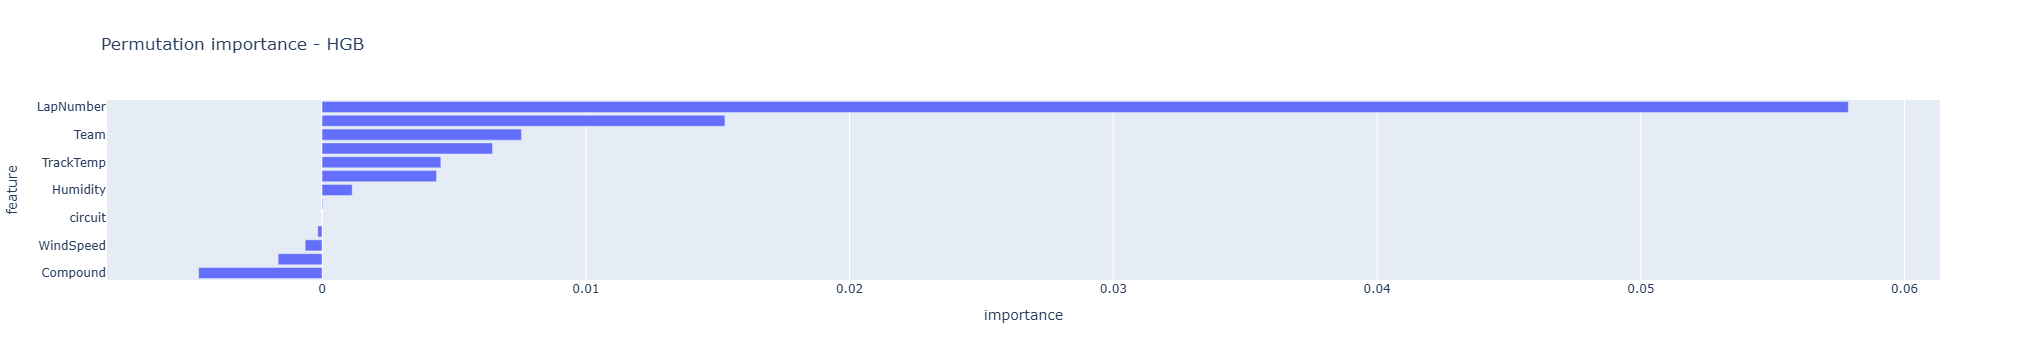

In [6]:
perm = permutation_importance(hgb, X_te_h, y_te, n_repeats=10, random_state=42)
imp = pd.DataFrame({'feature': features, 'importance': perm.importances_mean}
                   ).sort_values('importance')
fig = px.bar(imp, x='importance', y='feature', orientation='h',
             title='Permutation importance - HGB')
fig.show()

### Zapis predykcji pod analize bledow (notebook 05)

In [7]:
out = X_te.copy()
out['actual'] = y_te
out['pred_hgb'] = p_hgb
out['pred_lin'] = p_lin
out['Round'] = groups[te]
out.to_parquet('../data/reg_predictions.parquet', index=False)
print('zapisano ../data/reg_predictions.parquet', out.shape)

zapisano ../data/reg_predictions.parquet (4542, 17)
